In [1]:
from tqdm import tqdm
import numpy as np
from lmfit import minimize, Parameters, fit_report, Model
import pickle
import os
from pyne2001 import get_dm_full
import json
import corner
import sys
import pywt

from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, Planck15
import astropy.units as u

from scipy.signal import savgol_filter, resample, correlate, fftconvolve
import scipy
from scipy.fft import fft2, fftshift

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter

import importlib

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['cmr10']
rcParams['font.size'] = 25
rcParams['axes.formatter.use_mathtext'] = True
rcParams['axes.unicode_minus'] = False
rcParams['mathtext.fontset'] = 'cm'
rcParams['text.usetex'] = False

sys.path.insert(0,'/media/ubuntu/ssd/jfaber/dsa110-scat/utils')

import scinttools as sct
import burstfittools as bft


/home/ubuntu/anaconda3/envs/casa38/lib/python3.8/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: v0.0.0-44-gc4edec3-dirty is an invalid version and will not be supported in a future release
  warnings.warn(
/home/ubuntu/anaconda3/envs/casa38/lib/python3.8/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: v1.4.0-7-g6469766 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/ubuntu/anaconda3/envs/casa38/lib/python3.8/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 0.2.1-6-g1a8a603-dirty is an invalid version and will not be supported in a future release
  warnings.warn(
/home/ubuntu/anaconda3/envs/casa38/lib/python3.8/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 0.2.1-6-g1a8a603 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/ubuntu/anaconda3/envs/casa38/lib/python3.8/site-packages/pkg_resour

In [2]:
def dedisperse(data,dm,fch1=1498.75,reffreq=1530.,nf=6144,df=0.03051757812,nt=32768,dt=32.768e-3):
    
    # calculate number of samples in output
    delay = 4.15*dm*((1e-3*(fch1-(nf-1)*df))**(-2.) - (1e-3*reffreq)**(-2.))
    nsamp_delay = int(delay/dt)-1
    nsamp_output = nt-nsamp_delay
    print('outputting samples:',nsamp_output)
    
    # form output
    output_data = np.zeros((nf,nsamp_output))
    for i in np.arange(nf):
        
        f = 1e-3*(fch1-i*df)
        delay_samples = 4.15*dm*(f**(-2.) - (1e-3*reffreq)**(-2.))/dt
        x = np.arange(nsamp_output)+delay_samples
        xp = np.arange(nt)
        fp = data[i,:]
        output_data[i,:] = np.interp(x,xp,fp)
        
    return output_data

def sgolay2d (z, window_size, order, derivative=None):

    # number of terms in the polynomial expression
    n_terms = ( order + 1 ) * ( order + 2)  / 2.0
    
    if  window_size % 2 == 0:
        raise ValueError('window_size must be odd')
    
    if window_size**2 < n_terms:
        raise ValueError('order is too high for the window size')
    
    half_size = window_size // 2
    
    # exponents of the polynomial. 
    # p(x,y) = a0 + a1*x + a2*y + a3*x^2 + a4*y^2 + a5*x*y + ... 
    # this line gives a list of two item tuple. Each tuple contains 
    # the exponents of the k-th term. First element of tuple is for x
    # second element for y.
    # Ex. exps = [(0,0), (1,0), (0,1), (2,0), (1,1), (0,2), ...]
    exps = [ (k-n, n) for k in range(order+1) for n in range(k+1) ]
    
    # coordinates of points
    ind = np.arange(-half_size, half_size+1, dtype=np.float64)
    dx = np.repeat( ind, window_size )
    dy = np.tile( ind, [window_size, 1]).reshape(window_size**2, )
    
    # build matrix of system of equation
    A = np.empty( (window_size**2, len(exps)) )
    for i, exp in enumerate( exps ):
        A[:,i] = (dx**exp[0]) * (dy**exp[1])
        
    # pad input array with appropriate values at the four borders
    new_shape = z.shape[0] + 2*half_size, z.shape[1] + 2*half_size
    Z = np.zeros( (new_shape) )
    # top band
    band = z[0, :]
    Z[:half_size, half_size:-half_size] =  band -  np.abs( np.flipud( z[1:half_size+1, :] ) - band )
    # bottom band
    band = z[-1, :]
    Z[-half_size:, half_size:-half_size] = band  + np.abs( np.flipud( z[-half_size-1:-1, :] )  -band ) 
    # left band
    band = np.tile( z[:,0].reshape(-1,1), [1,half_size])
    Z[half_size:-half_size, :half_size] = band - np.abs( np.fliplr( z[:, 1:half_size+1] ) - band )
    # right band
    band = np.tile( z[:,-1].reshape(-1,1), [1,half_size] )
    Z[half_size:-half_size, -half_size:] =  band + np.abs( np.fliplr( z[:, -half_size-1:-1] ) - band )
    # central band
    Z[half_size:-half_size, half_size:-half_size] = z
    
    # top left corner
    band = z[0,0]
    Z[:half_size,:half_size] = band - np.abs( np.flipud(np.fliplr(z[1:half_size+1,1:half_size+1]) ) - band )
    # bottom right corner
    band = z[-1,-1]
    Z[-half_size:,-half_size:] = band + np.abs( np.flipud(np.fliplr(z[-half_size-1:-1,-half_size-1:-1]) ) - band ) 
    
    # top right corner
    band = Z[half_size,-half_size:]
    Z[:half_size,-half_size:] = band - np.abs( np.flipud(Z[half_size+1:2*half_size+1,-half_size:]) - band ) 
    # bottom left corner
    band = Z[-half_size:,half_size].reshape(-1,1)
    Z[-half_size:,:half_size] = band - np.abs( np.fliplr(Z[-half_size:, half_size+1:2*half_size+1]) - band ) 
    
    # solve system and convolve
    if derivative == None:
        m = np.linalg.pinv(A)[0].reshape((window_size, -1))
        return scipy.signal.fftconvolve(Z, m, mode='valid')
    elif derivative == 'col':
        c = np.linalg.pinv(A)[1].reshape((window_size, -1))
        return scipy.signal.fftconvolve(Z, -c, mode='valid')        
    elif derivative == 'row':
        r = np.linalg.pinv(A)[2].reshape((window_size, -1))
        return scipy.signal.fftconvolve(Z, -r, mode='valid')        
    elif derivative == 'both':
        c = np.linalg.pinv(A)[1].reshape((window_size, -1))
        r = np.linalg.pinv(A)[2].reshape((window_size, -1))
        return scipy.signal.fftconvolve(Z, -r, mode='valid'), scipy.signal.fftconvolve(Z, -c, mode='valid') 

def bandpasscorr_first(initrow, off_pulse_indices_time):
    #Effective bandpass correction
    row = (initrow - np.mean(initrow[off_pulse_indices_time])) / np.std(initrow[off_pulse_indices_time])
    return row


def bandpasscorr_sec(arr, off_pulse_indices_time):
    arr = [bandpasscorr_first(row, off_pulse_indices_time) for row in arr]
    arr = np.asarray(arr)
    #arr = np.nan_to_num(arr)
    return arr

def denoise_data(Y, mu, sigma, wavelet='db4', level=None):
    """
    Denoise 2D data with log-normal noise.
    
    Parameters:
    Y (ndarray): Noisy 2D data.
    mu (float): Mean of the underlying normal distribution for noise.
    sigma (float): Standard deviation of the underlying normal distribution.
    wavelet (str): Wavelet type (default 'db4').
    level (int): Decomposition level (auto-determined if None).
    
    Returns:
    ndarray: Denoised data.
    """
    # Step 1: Log transform
    log_Y = np.log(Y)
    
    # Step 2: Subtract mu to center the noise
    log_Y_centered = log_Y - mu
    
    # Step 3: Wavelet denoising
    wavelet_obj = pywt.Wavelet(wavelet)
    if level is None:
        max_level_x = pywt.dwt_max_level(log_Y_centered.shape[1], wavelet_obj.dec_len)
        max_level_y = pywt.dwt_max_level(log_Y_centered.shape[0], wavelet_obj.dec_len)
        #level = pywt.dwt_max_level(log_Y_centered.shape, wavelet)
        max_level = min(max_level_x, max_level_y)
        level = min(level, max_level) if level is not None else max_level
        print('Automatically Calculated Level:', level)

    else:
        print('Manually Specified Level:', level)
    
    coeffs = pywt.wavedec2(log_Y_centered, wavelet, level=level)
    
    coeffs_thresh = [coeffs[0]]
    for i, c in enumerate(coeffs[1:]):
        if i == 0:  # Level 1 (peak): Less aggressive thresholding
            thresh = 0.5 * sigma * np.sqrt(2 * np.log(c[0].size))
        else:       # Levels 2+ (tail): Moderate thresholding
            thresh = sigma * np.sqrt(2 * np.log(c[0].size))
        coeffs_thresh.append(tuple(pywt.threshold(detail, thresh, 'soft') for detail in c))
    
    # Reconstruct
    denoised_log_centered = pywt.waverec2(coeffs_thresh, wavelet)
    
    # Trim to original shape if necessary
    denoised_log_centered = denoised_log_centered[:Y.shape[0], :Y.shape[1]]
    
    # Step 4: Add back mu and exponentiate
    denoised_log = denoised_log_centered + mu
    S_est = np.exp(denoised_log)
    
    return S_est

In [3]:
from sigpyproc.Readers import FilReader
fil = '/dataz/dsa110/candidates/221219aabz/Level3/221219aabz_dev_polcal_I.fil'
reader = FilReader(fil)
nsamples = reader.header.nsamples
data_fil = FilReader(fil).readBlock(0,nsamples)
data_fil_lim = data_fil[:, 10500:20000]
np.save('nihari_10500_20000.npy', data_fil_lim)
# All relevant info can be found in the header
#for key, value in header.items():
#    print(f"{key}: {value}")

In [4]:
# Load data
name = "nihari_221219aabz"
#data = np.load(f"./data/{name}/{name.split("_")[0]}_14000_16500.npy")
data_npy = np.load(f'{name.split("_")[0]}_10500_20000.npy')
data_dd = dedisperse(data_npy, 0.0, fch1=1498.75, reffreq=1530., nf=6144, df=0.03051757812, nt=9500, dt=32.768e-3)
data_dd_lim = np.nan_to_num(data_dd[:, 0:9500])
data_dd_lim = data_dd_lim + np.abs(np.min(data_dd_lim)) + 1e-6

# Estimate noise for inner and outer 1/5 of the data
#off_pulse_indices = np.concatenate([
#            np.arange(0, data_dd_lim.shape[1] // 5),
#            np.arange(4 * data_dd_lim.shape[1] // 5, data_dd_lim.shape[1])
#        ])
#off_pulse_data = data_dd_lim[:, off_pulse_indices]
## Estimate noise using the off-pulse data
#noise_std_toadd = np.mean(np.std(off_pulse_data, axis=1))
#print('Noise Shape:', noise_std_toadd.shape)
# Estimate noise for inner and outer 1/5 of the data
off_pulse_indices_time = np.concatenate([
            np.arange(0, data_dd_lim.shape[1] // 5),
            np.arange(4 * data_dd_lim.shape[1] // 5, data_dd_lim.shape[1])
        ])
all_pulse_indices_freq = np.concatenate([np.arange(0, 431), np.arange(457, 3070), np.arange(3082, 6043)])
# Estimate noise using the off-pulse data
off_pulse_data = data_dd_lim[:, off_pulse_indices_time]
noise_mu_toadd = np.nanmean(np.log(off_pulse_data[all_pulse_indices_freq, :]))
noise_std_toadd = np.nanstd(np.log(off_pulse_data[all_pulse_indices_freq, :]), ddof=1)
print('Noise Shape:', noise_std_toadd.shape)
print('Noise (mu):', noise_mu_toadd)
print('Noise (sigma):', noise_std_toadd)
print('Noise Term Weight in Bayesian De-Noising:', 1/(2*noise_std_toadd**2))

# Add noise to the data where there are zeros
data_dd_lim_clean = data_dd_lim.copy()
#data_dd_lim_clean[6044:6144, :] = np.random.normal(loc=0.0, scale=noise_std_toadd[6044:6144, np.newaxis], size=(100, 9500))
#data_dd_lim_clean[432:456, :] = np.random.normal(loc=0.0, scale=noise_std_toadd[432:456, np.newaxis], size=(24, 9500))
data_dd_lim_clean[6044:6144, :] = np.random.lognormal(mean=noise_mu_toadd, sigma=noise_std_toadd, size=(100, 9500))
data_dd_lim_clean[3071:3081, :] = np.random.lognormal(mean=noise_mu_toadd, sigma=noise_std_toadd, size=(10, 9500))
data_dd_lim_clean[432:456, :] = np.random.lognormal(mean=noise_mu_toadd, sigma=noise_std_toadd, size=(24, 9500))
#data_dd_lim_clean = data_dd_lim_clean - np.abs(np.min(data_dd_lim)) - 1e-6
print('Cleaned Data Shape:', data_dd_lim_clean.shape)
#data_dd_lim_clean_bpc = bandpasscorr_sec(data_dd_lim_clean)

outputting samples: 9501
Noise Shape: ()
Noise (mu): 0.26220113423368024
Noise (sigma): 0.20778004738304945
Noise Term Weight in Bayesian De-Noising: 11.581433621936187
Cleaned Data Shape: (6144, 9500)


In [5]:
#data_dd_lim_clean_bpc = bandpasscorr_sec(data_dd_lim_clean, off_pulse_indices_time)

smoothing_kernel = 71
smoothing_polyorder = 3

data_smooth = savgol_filter(data_dd_lim_clean[:, :], smoothing_kernel, smoothing_polyorder) #np.nanmean(data_dd_lim[:, 4000:7000]), 91, 3)
data_smooth_bpc = bandpasscorr_sec(data_smooth, off_pulse_indices_time)
data_smooth_spectrum = np.nansum(data_smooth, axis=1)
data_smooth_spectrum = data_smooth_spectrum - np.nanmean(data_smooth_spectrum)
data_smooth_spectrum = data_smooth_spectrum / np.nanstd(data_smooth_spectrum)
data_smooth_timeseries = np.nansum(data_smooth, axis=0)
data_smooth_timeseries = data_smooth_timeseries - np.nanmean(data_smooth_timeseries)
data_smooth_timeseries = data_smooth_timeseries / np.nanstd(data_smooth_timeseries)
print('Smoothed & Cleaned Data Shape:', data_smooth.shape)

Smoothed & Cleaned Data Shape: (6144, 9500)


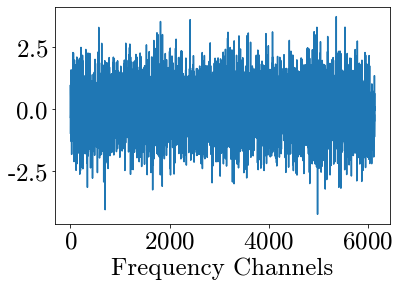

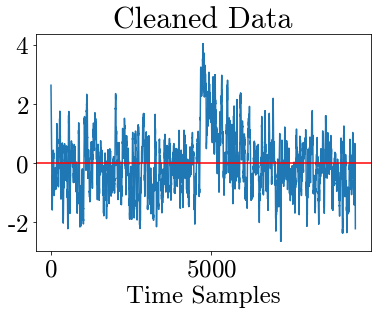

In [6]:
plt.plot(data_smooth_spectrum)
plt.xlabel('Frequency Channels')
plt.show()
plt.plot(data_smooth_timeseries)
plt.xlabel('Time Samples')
plt.axhline(0, c = 'r')
plt.title('Cleaned Data')
plt.show()

In [7]:
#off_pulse_clean_indices = np.concatenate([
#            np.arange(0, data_dd_lim_clean.shape[1] // 5),
#            np.arange(4 * data_dd_lim_clean.shape[1] // 5, data_dd_lim_clean.shape[1])
#        ])
## Estimate noise using the off-pulse data
#off_pulse_data_clean = data_dd_lim_clean[:, off_pulse_clean_indices]
#off_pulse_data_clean = off_pulse_data_clean + np.abs(np.min(off_pulse_data_clean)) + 1e-6
#noise_mu = np.nanmean(np.log(off_pulse_data_clean[460:6000, :]))
#noise_std = np.nanstd(np.log(off_pulse_data_clean[460:6000, :]), ddof=1)
#
#data_denoised_db4 = denoise_data(data_dd_lim_clean, noise_mu, noise_std, wavelet='db4', level=4)
#data_denoised_bpc_db4 = bandpasscorr_sec(data_denoised_db4, off_pulse_indices_time)
#data_denoised_db6 = denoise_data(data_dd_lim_clean, noise_mu, noise_std, wavelet='db6', level=4)
#data_denoised_bpc_db6 = bandpasscorr_sec(data_denoised_db6, off_pulse_indices_time)
#data_denoised_bior3p5 = denoise_data(data_dd_lim_clean, noise_mu, noise_std, wavelet='bior3.5', level=4)
#data_denoised_bpc_bior3p5 = bandpasscorr_sec(data_denoised_bior3p5, off_pulse_indices_time)
#
#plt.plot(np.nansum(data_denoised_bpc_db4, axis=1))
#plt.xlabel('Frequency Channels')
#plt.show()
#plt.plot(np.nansum(data_denoised_bpc_db4, axis=0))
#plt.xlabel('Time Samples')
#plt.axhline(0, c = 'r')
#plt.title('DB4')
#plt.show()
#
#plt.plot(np.nansum(data_denoised_bpc_db6, axis=1))
#plt.xlabel('Frequency Channels')
#plt.show()
#plt.plot(np.nansum(data_denoised_bpc_db6, axis=0))
#plt.xlabel('Time Samples')
#plt.axhline(0, c = 'r')
#plt.title('DB6')
#plt.show()
#
#plt.plot(np.nansum(data_denoised_bpc_bior3p5, axis=1))
#plt.xlabel('Frequency Channels')
#plt.show()
#plt.plot(np.nansum(data_denoised_bpc_bior3p5, axis=0))
#plt.xlabel('Time Samples')
#plt.axhline(0, c = 'r')
#plt.title('BIOR3p5')
#plt.show()

In [8]:
#data_denoised_bpc_db4_norm = data_denoised_bpc_db4 - np.mean(data_denoised_bpc_db4)
#data_denoised_bpc_db4_norm = data_denoised_bpc_db4_norm / np.max(data_denoised_bpc_db4_norm)
#data_denoised_bpc_db6_norm = data_denoised_bpc_db6 - np.mean(data_denoised_bpc_db6)
#data_denoised_bpc_db6_norm = data_denoised_bpc_db6_norm / np.max(data_denoised_bpc_db6_norm)
#data_denoised_bpc_bior3p5_norm = data_denoised_bpc_bior3p5 - np.mean(data_denoised_bpc_bior3p5)
#data_denoised_bpc_bior3p5_norm = data_denoised_bpc_bior3p5_norm / np.max(data_denoised_bpc_bior3p5_norm)

[<AxesSubplot:> <AxesSubplot:>]
[<AxesSubplot:> <AxesSubplot:>]


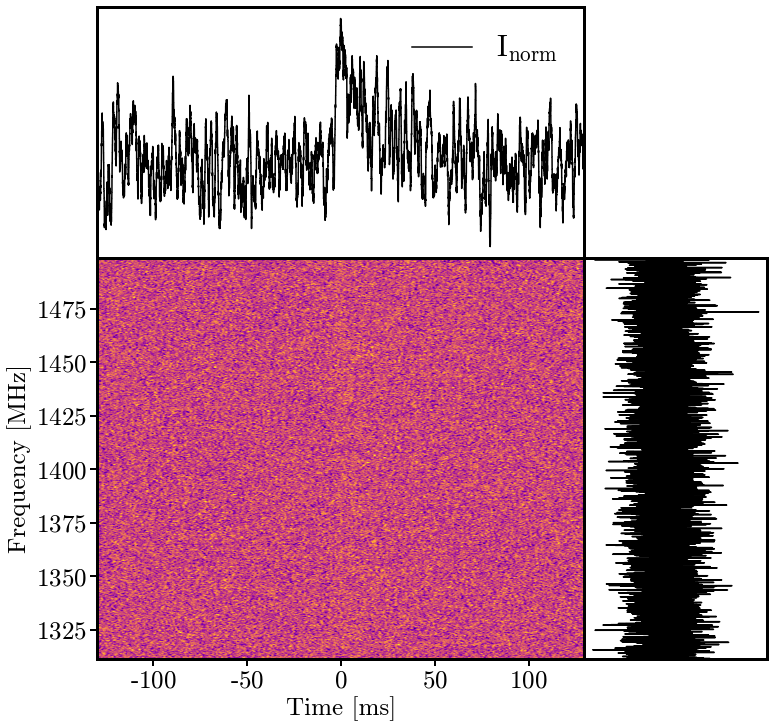

In [9]:
tres = 32.768e-3 #ms #data['delta_t (ms)']
fres = 0.03051757812 #MHz #data['delta_f (MHz)']
fres_kHz = fres*1e3
f_min = 1311.25 #MHz, the addition is to account for the 100 channels that were removed from bottom of the band
f_max = 1498.75 #MHz #data['fch1 (MHz)'] + data['df (MHz)']*data['nchans']

intensity = data_smooth_bpc #data['I']
outerbound = int(intensity.shape[1] * 1/12)

intensity = intensity[:, outerbound:-outerbound]

timeseries = np.nansum(intensity, axis = 0)
timesamples = np.linspace(0, intensity.shape[1]*tres, intensity.shape[1])
timerange = np.abs(timesamples[-1] - timesamples[0])
timesamples_mod = np.linspace(-timerange/2, timerange/2, len(timesamples))
timeshift = -1 * int(timesamples_mod[np.argmax(savgol_filter(timeseries, 51, 3))] / tres)

intensity = np.roll(intensity, timeshift, axis = 1)
intensity_norm = intensity / np.nanmax(intensity)
spectrum = np.nansum(intensity, axis = 1)
spectrum_norm = spectrum / np.nanmax(spectrum)
freqsamples = np.linspace(f_min, f_max, intensity.shape[0])
timeseries = np.nansum(intensity, axis = 0)
timeseries_norm = timeseries / np.nanmax(timeseries)

from matplotlib.colors import LogNorm

fig, axes = plt.subplots(
        nrows=2, ncols=2, sharex=False, sharey=False, 
        gridspec_kw={'height_ratios':[1.25,2], 'width_ratios':[2, 0.75]},
        figsize = (12, 12))

# Increase border thickness
current_axes = plt.gca()
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
for ax_row in axes:
    print(ax_row)
    for ax in ax_row:
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis = 'y', length=5)

axes[0, 0].step(timesamples_mod, timeseries_norm, where = 'mid', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
#axes[0, 0].set_yticks([0, 1])
axes[0, 0].tick_params(axis='x',
        which='both', 
        bottom=False, 
        top=False, 
        labelbottom=False,
        width=2)
axes[0, 0].set_yticks([])
axes[0, 0].set_xlim(timesamples_mod[0], timesamples_mod[-1])
axes[0, 0].legend(loc = 'upper right', fontsize = 30, frameon = False)

#from astropy.visualization import (PercentileInterval, LogStretch, PowerStretch, ManualInterval, ZScaleInterval, ImageNormalize)
#norm = ImageNormalize(intensity_norm, interval=PercentileInterval(0.5)) #, stretch=LogStretch())
#axes[1, 0].imshow(intensity_norm, norm=norm, extent = [timesamples_mod[0], timesamples_mod[-1], freqsamples[0], freqsamples[-1]], cmap = 'plasma', aspect = 'auto') #

mean = np.nanmean(intensity_norm)
std = np.nanstd(intensity_norm)
axes[1, 0].imshow(intensity_norm, vmin = mean - 1*std, vmax = mean + 1*std, extent = [timesamples_mod[0], timesamples_mod[-1], freqsamples[0], freqsamples[-1]], cmap = 'plasma', aspect = 'auto') 
#axes[1, 0].imshow(intensity_norm, norm=LogNorm(), extent = [timesamples_mod[0], timesamples_mod[-1], freqsamples[0], freqsamples[-1]], cmap = 'plasma', aspect = 'auto') 
axes[1, 0].set_ylabel('Frequency [MHz]')
axes[1, 0].set_xlabel('Time [ms]')
axes[1, 0].tick_params(which='both', width=2)
axes[1, 0].tick_params(which='major', length=7)
axes[1, 0].tick_params(which='minor', length=5)
axes[1, 0].tick_params(which='minor', axis = 'y', length=5)

axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

axes[1, 1].step(np.flip(spectrum_norm), freqsamples, where='pre', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
axes[1, 1].tick_params(axis='y',
        which='both', 
        left=False, 
        right=False, 
        labelleft=False,
        width=2)
axes[1, 1].set_xticks([])
axes[1, 1].set_ylim(freqsamples[0], freqsamples[-1])
#axes[2].legend(loc = 'upper right', fontsize = 30, frameon = False)

#axes[1].set_xlim(40, 150)
plt.subplots_adjust(hspace=0)
plt.subplots_adjust(wspace=0)

fig.savefig(f'{name}_fullres_wfall.pdf', bbox_inches = 'tight')

plt.show()

In [10]:
f_factor = 192*8
t_factor = 8
intensity_ds = bft.downsample_data(intensity, f_factor = f_factor, t_factor = t_factor)
intensity_ds_nosmooth = bft.downsample_data(intensity, f_factor = f_factor, t_factor = t_factor)

Power Shape (frequency axis): 6144
Power Shape (time axis): 7918
Nearest Multiple To Downsampling Factor (frequency): 6144
Nearest Multiple To Downsampling Factor (time): 7912
Downsampled Data Shape: (4, 989)
Power Shape (frequency axis): 6144
Power Shape (time axis): 7918
Nearest Multiple To Downsampling Factor (frequency): 6144
Nearest Multiple To Downsampling Factor (time): 7912
Downsampled Data Shape: (4, 989)


[<AxesSubplot:> <AxesSubplot:>]
[<AxesSubplot:> <AxesSubplot:>]


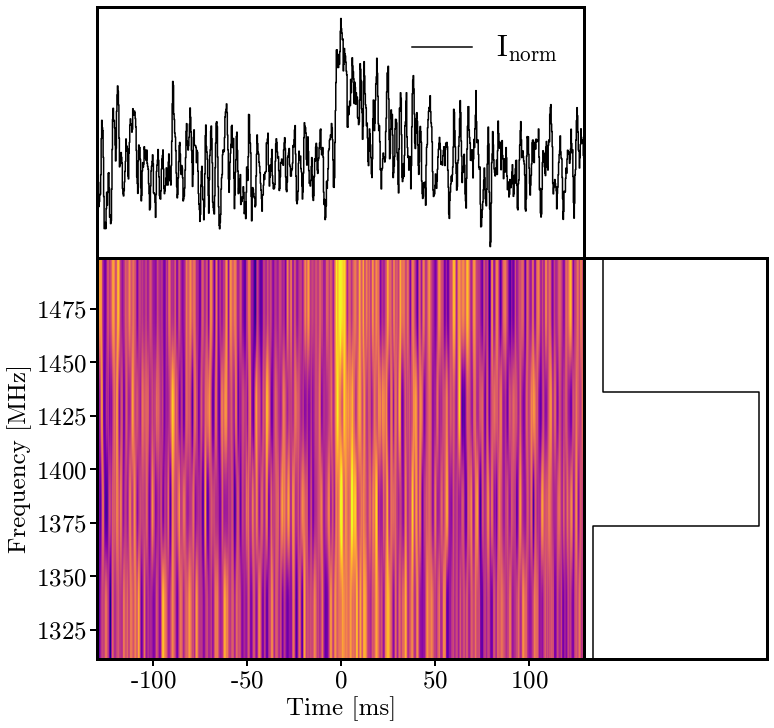

In [11]:
fres_ds = fres * f_factor
tres_ds = tres * t_factor

intensity_ds_norm = intensity_ds / np.max(intensity_ds)
timeseries_ds = np.nansum(intensity_ds, axis = 0)
timeseries_ds = timeseries_ds - np.nanmean(timeseries_ds)
timeseries_ds = timeseries_ds / np.nanstd(timeseries_ds)
timeseries_ds_norm = timeseries_ds / np.max(timeseries_ds)
timesamples_ds = np.linspace(0, intensity_ds.shape[1]*tres_ds, intensity_ds.shape[1])
timerange_ds = np.abs(timesamples_ds[-1] - timesamples_ds[0])
timesamples_mod_ds = np.linspace(-timerange_ds/2, timerange_ds/2, len(timesamples_ds))
spectrum_ds = np.nansum(intensity_ds, axis = 1)
spectrum_ds = spectrum_ds - np.nanmean(spectrum_ds)
spectrum_ds = spectrum_ds / np.nanstd(spectrum_ds)
spectrum_ds_norm = spectrum_ds / np.max(spectrum_ds)
freqsamples_ds = np.linspace(f_min, f_max, intensity_ds.shape[0])

#spectrum = np.nansum(intensity_ds, axis = 1)
#timeseries = np.nansum(intensity_ds, axis = 0)

from matplotlib.colors import LogNorm

fig, axes = plt.subplots(
        nrows=2, ncols=2, sharex=False, sharey=False, 
        gridspec_kw={'height_ratios':[1.25,2], 'width_ratios':[2, 0.75]},
        figsize = (12, 12))

# Increase border thickness
current_axes = plt.gca()
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
for ax_row in axes:
    print(ax_row)
    for ax in ax_row:
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis = 'y', length=5)

axes[0, 0].step(timesamples_mod_ds, timeseries_ds_norm, where = 'mid', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
#axes[0, 0].set_yticks([0, 1])
axes[0, 0].tick_params(axis='x',
        which='both', 
        bottom=False, 
        top=False, 
        labelbottom=False,
        width=2)
axes[0, 0].set_yticks([])
axes[0, 0].set_xlim(timesamples_mod_ds[0], timesamples_mod_ds[-1])
axes[0, 0].legend(loc = 'upper right', fontsize = 30, frameon = False)

mean_ds = np.nanmean(intensity_ds_norm)
std_ds = np.nanstd(intensity_ds_norm)
axes[1, 0].imshow(intensity_ds_norm, vmin = mean_ds - 3*std_ds, vmax = mean_ds + 3*std_ds, extent = [timesamples_mod_ds[0], timesamples_mod_ds[-1], freqsamples_ds[0], freqsamples_ds[-1]], cmap = 'plasma', aspect = 'auto')#, interpolation='nearest') 
#axes[1, 0].imshow(intensity_ds_norm, extent = [timesamples_mod_ds[0], timesamples_mod_ds[-1], freqsamples_ds[0], freqsamples_ds[-1]], cmap = 'plasma', aspect = 'auto')#, interpolation='nearest') 
axes[1, 0].set_ylabel('Frequency [MHz]')
axes[1, 0].set_xlabel('Time [ms]')
axes[1, 0].tick_params(which='both', width=2)
axes[1, 0].tick_params(which='major', length=7)
axes[1, 0].tick_params(which='minor', length=5)
axes[1, 0].tick_params(which='minor', axis = 'y', length=5)

axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

axes[1, 1].step(np.flip(spectrum_ds_norm), freqsamples_ds, where='pre', c = 'k', alpha = 1, label = 'I$_{\mathrm{norm}}$')
axes[1, 1].tick_params(axis='y',
        which='both', 
        left=False, 
        right=False, 
        labelleft=False,
        width=2)
axes[1, 1].set_xticks([])
axes[1, 1].set_ylim(freqsamples_ds[0], freqsamples_ds[-1])
#axes[2].legend(loc = 'upper right', fontsize = 30, frameon = False)

#axes[1].set_xlim(40, 150)
plt.subplots_adjust(hspace=0)
plt.subplots_adjust(wspace=0)

fig.savefig(f'{name}_lowres_wfall.pdf', bbox_inches = 'tight')

plt.show()

In [22]:
importlib.reload(bft)

<module 'burstfittools' from '/media/ubuntu/ssd/jfaber/dsa110-scat/utils/burstfittools.py'>

In [23]:
n_channels = intensity_ds.shape[0]
n_samples = intensity_ds.shape[1]

# Create time array (ms)
time = np.linspace(0, n_samples*tres_ds, n_samples)

# Create frequency array with 128 channels
f_b = 1.31125  # GHz
f_t = 1.49875    # GHz
freq = np.linspace(f_b, f_t, n_channels)

# Set parameters for Model 3
#c0 = 1.0  # Reference flux at reference frequency
#spectral_index = 2.5
#t0 = 1.0  # ms
dm_init = 0.0
#DM_err = 0.0
#zeta = 0.08
#tau_1GHz = 0.6
#alpha = 4.0

# Parameters array for model 3
#params = [c0, spectral_index, t0, DM_err, zeta, tau_1GHz, alpha]

# Initialize the model and data
#data = np.zeros((N_channels, N_time_samples))
model_instance = bft.FRBModel(intensity_ds_norm, time, freq, dm_init)

# Add Gaussian noise to the simulated data
#np.random.seed(42)  # For reproducibility
#noise_level = 0.05 * np.max(simulated_data)  # Adjust noise level as needed
#noise = noise_level * np.random.randn(*simulated_data.shape)
#simulated_data_noisy = simulated_data + noise
#simulated_data_timeseries = simulated_data_noisy.sum(0) / np.max(simulated_data_noisy.sum(0))

Noise Sigma:  [0.23987606 0.22653749 0.22557073 0.22162815]


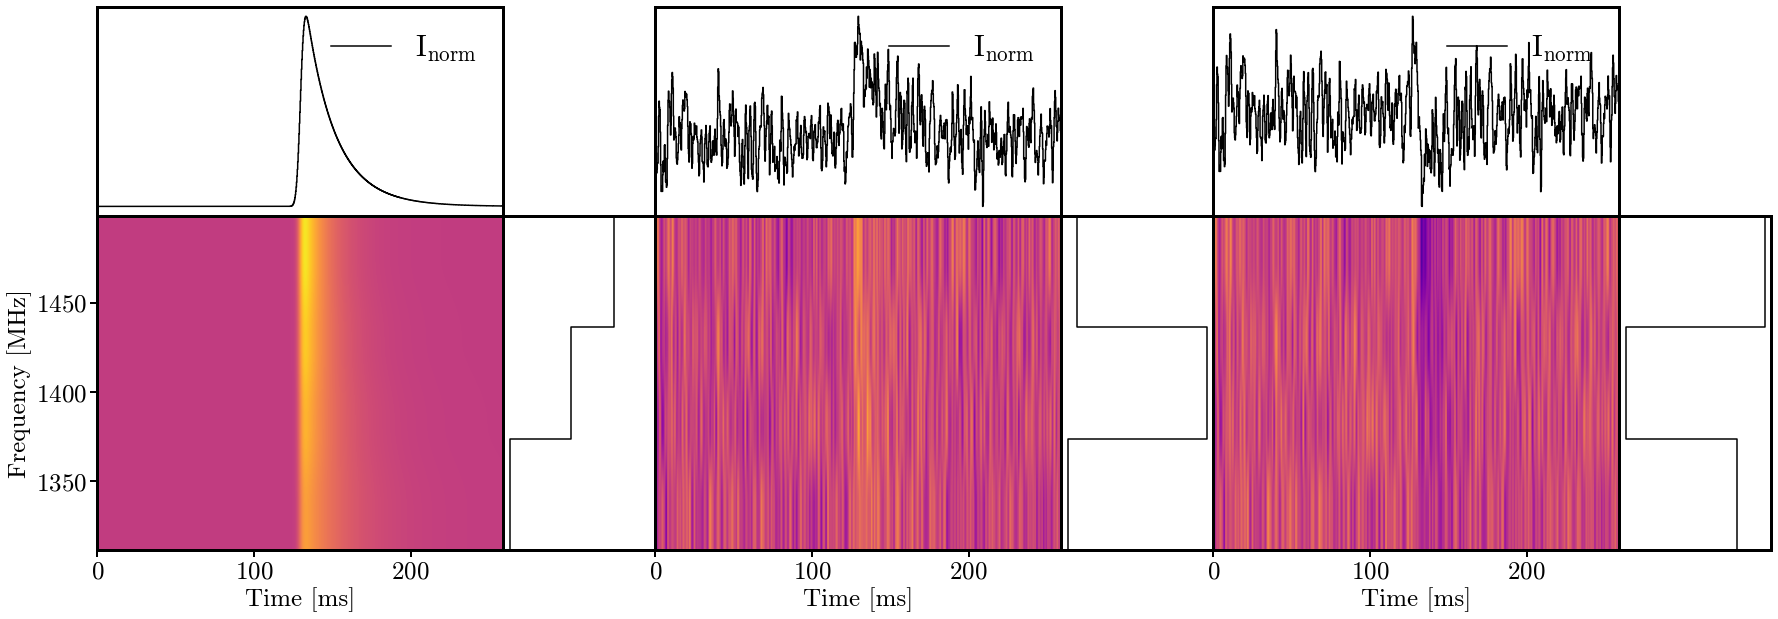

In [24]:
# --- (Assuming the simulated data and real data arrays have already been defined) ---
from scipy.signal import savgol_filter
# Generate simulated data (as in your original code)
c0_init = np.max(np.sum(intensity_ds_norm, axis=1))# / intensity_ds_norm.shape[1]
t0_init = timesamples_ds[np.argmax(np.sum(savgol_filter(intensity_ds_norm, 11, 3), axis=0))]
gamma_init = 0.1
#DM_err_init = 0.0
zeta_init = 2
tau_init = 74
#alpha_init = 4.0

model_type = 'model3'
if model_type == 'model0':
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, 0., 0.]
    sim_params = [c0_init, t0_init, gamma_init, 0., 0.]
elif model_type == 'model1':
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, zeta_init, 0.]
    sim_params = [c0_init, t0_init, gamma_init, zeta_init, 0.]
elif model_type == 'model2':
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, tau_init, alpha_init, 0.]
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, tau_init, 0.]
    sim_params = [c0_init, t0_init, gamma_init, tau_init, 0.]
elif model_type == 'model3':
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, zeta_init, tau_init, alpha_init]
    #sim_params = [c0_init, t0_init, gamma_init, DM_err_init, zeta_init, tau_init]
    sim_params = [c0_init, t0_init, gamma_init, zeta_init, tau_init]

simulated_data = model_instance.model(sim_params, model_type=model_type)
simulated_data_norm = simulated_data / np.max(simulated_data)

sim_fres = fres_ds
sim_tres = tres_ds
sim_timeseries = np.nansum(simulated_data, axis=0)
sim_timeseries_norm = sim_timeseries / np.max(sim_timeseries)
sim_timesamples = np.linspace(0, simulated_data.shape[1]*sim_tres, simulated_data.shape[1])
sim_timerange = np.abs(sim_timesamples[-1] - sim_timesamples[0])
sim_timesamples_mod = np.linspace(-sim_timerange/2, sim_timerange/2, len(sim_timesamples))
sim_spectrum = np.nansum(simulated_data, axis=1)
sim_spectrum_norm = sim_spectrum / np.max(sim_spectrum)
sim_freqsamples = np.linspace(f_min, f_max, simulated_data.shape[0])

# Compute residuals and residual spectrum
intensity_rsdl = intensity_ds_norm - simulated_data_norm
timeseries_rsdl = timeseries_ds_norm - sim_timeseries_norm
rsdl_spectrum = np.nansum(intensity_rsdl, axis=1)
rsdl_spectrum_norm = rsdl_spectrum / np.max(rsdl_spectrum)

# Precompute means and stds for imshow scaling
sim_mean = np.nanmean(simulated_data_norm)
sim_std = np.nanstd(simulated_data_norm)
mean_ds = np.nanmean(intensity_ds_norm)
std_ds = np.nanstd(intensity_ds_norm)
mean_rsdl = np.nanmean(intensity_rsdl)
std_rsdl = np.nanstd(intensity_rsdl)

# Create a figure with 2 rows x 6 columns:
# Columns 0-1: Panel 1 (Simulated/Model)
# Columns 2-3: Panel 2 (Real Data)
# Columns 4-5: Panel 3 (Residual)
fig, axes = plt.subplots(
    nrows=2, ncols=6, sharex=False, sharey=False,
    gridspec_kw={'height_ratios': [1.25, 2],
                 'width_ratios': [2, 0.75, 2, 0.75, 2, 0.75]},
    figsize=(30, 10)
)

# Increase border thickness and set tick parameters for every axis
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis='y', length=5)

# ----- PANEL 1: Simulated Data (Model) -----
# Timeseries (top left of panel 1: column 0)
axes[0, 0].step(sim_timesamples, sim_timeseries_norm, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
axes[0, 0].set_yticks([])
axes[0, 0].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 0].set_xlim(sim_timesamples[0], sim_timesamples[-1])
axes[0, 0].legend(loc='upper right', fontsize=30, frameon=False)

# Waterfall (bottom left of panel 1: column 0)
axes[1, 0].imshow(simulated_data_norm,
                   vmin=sim_mean - 6*sim_std, vmax=sim_mean + 6*sim_std,
                   extent=[sim_timesamples[0], sim_timesamples[-1], sim_freqsamples[0], sim_freqsamples[-1]],
                   cmap='plasma', aspect='auto')
axes[1, 0].set_ylabel('Frequency [MHz]')
axes[1, 0].set_xlabel('Time [ms]')

# Spectrum (bottom right of panel 1: column 1)
axes[1, 1].step(np.flip(sim_spectrum_norm), sim_freqsamples, where='pre', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_xticks([])
axes[1, 1].set_ylim(sim_freqsamples[0], sim_freqsamples[-1])
axes[1, 1].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 1)
axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

# ----- PANEL 2: Real Data -----
# Timeseries (top left of panel 2: column 2)
axes[0, 2].step(timesamples_ds, timeseries_ds_norm, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
axes[0, 2].set_yticks([])
axes[0, 2].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 2].set_xlim(timesamples_ds[0], timesamples_ds[-1])
axes[0, 2].legend(loc='upper right', fontsize=30, frameon=False)

# Waterfall (bottom left of panel 2: column 2)
axes[1, 2].imshow(intensity_ds_norm,
                   vmin=mean_ds - 6*std_ds, vmax=mean_ds + 6*std_ds,
                   extent=[timesamples_ds[0], timesamples_ds[-1], freqsamples_ds[0], freqsamples_ds[-1]],
                   cmap='plasma', aspect='auto')
#axes[1, 2].set_ylabel('Frequency [MHz]')
axes[1, 2].set_yticks([])
axes[1, 2].set_xlabel('Time [ms]')

# Spectrum (bottom right of panel 2: column 3)
axes[1, 3].step(np.flip(spectrum_ds_norm), freqsamples_ds, where='pre', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 3].set_xlabel('Intensity')
axes[1, 3].set_xticks([])
axes[1, 3].set_ylim(freqsamples_ds[0], freqsamples_ds[-1])
axes[1, 3].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 3)
axes[0, 3].axis('off')
axes[0, 3].set_visible(False)

# ----- PANEL 3: Residuals -----
# Timeseries residual (top left of panel 3: column 4)
axes[0, 4].step(sim_timesamples, timeseries_rsdl, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
axes[0, 4].set_yticks([])
axes[0, 4].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 4].set_xlim(sim_timesamples[0], sim_timesamples[-1])
axes[0, 4].legend(loc='upper right', fontsize=30, frameon=False)

# Waterfall residual (bottom left of panel 3: column 4)
axes[1, 4].imshow(intensity_rsdl,
                   vmin=mean_rsdl - 6*std_rsdl, vmax=mean_rsdl + 6*std_rsdl,
                   extent=[sim_timesamples[0], sim_timesamples[-1], sim_freqsamples[0], sim_freqsamples[-1]],
                   cmap='plasma', aspect='auto')
#axes[1, 4].set_ylabel('Frequency [MHz]')
axes[1, 4].set_yticks([])
axes[1, 4].set_xlabel('Time [ms]')

# Spectrum for residuals (bottom right of panel 3: column 5)
axes[1, 5].step(np.flip(rsdl_spectrum_norm), sim_freqsamples, where='pre', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 5].set_xlabel('Intensity')
axes[1, 5].set_xticks([])
axes[1, 5].set_ylim(sim_freqsamples[0], sim_freqsamples[-1])
axes[1, 5].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 5)
axes[0, 5].axis('off')
axes[0, 5].set_visible(False)
plt.subplots_adjust(hspace=0, wspace=0)

fig.savefig(f'{name}_initmodel_threepanel.pdf', bbox_inches = 'tight')

plt.show()


In [25]:
# Fit the models
prior_bounds = {
        'c0': (1e-3, 100),  # Adjusted as per prior
        't0': (t0_init - 10, t0_init + 10),
        'spectral_index': (-4, 4),
        #'DM_err': (-0.1, 0.1),
        'zeta': (0, 20),
        'tau_1GHz': (20, 150)
        #'alpha': (3.999999, 4.000001)
    }

nsteps = 500

results, best_model = bft.fit_models(model_instance, sim_params, prior_bounds, numsteps=nsteps, fit_m0=False, fit_m1=True, fit_m2=False, fit_m3=True)
print('\n')
print(f"The best-fitting model is: {best_model}")
print('\n')
print(results)

Check Prior Bounds:  {'c0': (0.001, 100), 't0': (119.8926173279352, 139.8926173279352), 'spectral_index': (-4, 4), 'zeta': (0, 20), 'tau_1GHz': (20, 150)}
Fitting Model 1


 46%|████▌     | 230/500 [00:02<00:03, 78.20it/s]

100%|██████████| 500/500 [00:06<00:00, 77.45it/s]


Fitting Model 3


100%|██████████| 500/500 [00:39<00:00, 12.71it/s]

Difference in BIC is greater than 6, the best model is model3!
Difference in BIC is greater than 6, the best model is model3!
Difference in BIC is greater than 6, the best model is model3!
Difference in BIC is greater than 6, the best model is model3!
Best model is model3


The best-fitting model is: model3


{'model0': {'sampler': nan, 'BIC': nan, 'lnL_max': nan, 'k': nan}, 'model1': {'sampler': <emcee.ensemble.EnsembleSampler object at 0x7efb21cb8160>, 'BIC': -214.54109712574683, 'lnL_max': 123.83652594835863, 'k': 4}, 'model2': {'sampler': nan, 'BIC': nan, 'lnL_max': nan, 'k': nan}, 'model3': {'sampler': <emcee.ensemble.EnsembleSampler object at 0x7efb21d5bb80>, 'BIC': -360.2413247798507, 'lnL_max': 200.82813412178186, 'k': 5}}


In [30]:
# Extract the sampler
best_sampler = results[best_model]['sampler']

print("Mean acceptance fraction (should be 0.2-0.5):", np.mean(best_sampler.acceptance_fraction))

# Check for NaN or Inf in Sampler
log_probs = best_sampler.get_log_prob()
if np.any(~np.isfinite(log_probs)):
    print("Found NaN or Inf in log-probabilities.")

#samples = best_sampler.get_chain(flat=True)
# Discard burn-in samples
burn_in = nsteps // 2
# Extract the samples
samples = best_sampler.get_chain(discard=burn_in, flat=True)
# Extract the log probability
log_prob = best_sampler.get_log_prob(discard=burn_in, flat=True)

# Determine the indices of the relevant parameters
if best_model == 'model0':
    #param_indices = [0, 1, 2, 3]  # c0, spectral_index, t0, DM_err
    param_indices = [0, 1, 2]
elif best_model == 'model1':
    #param_indices = [0, 1, 2, 3, 4]  # + zeta
    param_indices = [0, 1, 2, 3]
elif best_model == 'model2':
    #param_indices = [0, 1, 2, 3, 4, 5]  # + tau_1GHz, alpha
    #param_indices = [0, 1, 2, 3, 4]
    param_indices = [0, 1, 2, 3]
elif best_model == 'model3':
    #param_indices = [0, 1, 2, 3, 4, 5, 6]  # + zeta, tau_1GHz, alpha
    #param_indices = [0, 1, 2, 3, 4, 5]
    param_indices = [0, 1, 2, 3, 4]

# Extract the relevant samples
relevant_samples = samples[:, param_indices]

# Extract the relevant true parameter values
#truths = [params[i] for i in param_indices]

# Define labels for the parameters
#labels = ['c0', 't0', 'spectral_index', 'DM_err']
labels = ['c0', 't0', 'spectral_index']
if best_model in ['model1', 'model3']:
    labels.append('zeta')
if best_model in ['model2', 'model3']:
    #labels.extend(['tau_1GHz', 'alpha'])
    labels.extend(['tau_1GHz'])

# Plot trace plots to assess convergence
#ndim = relevant_samples.shape[1]
#fig, axes = plt.subplots(ndim, figsize=(15, 10), sharex=True)
#for i in range(ndim):
#    axes[i].plot(samples[:, i], "k", alpha=0.3)
#    axes[i].set_ylabel(labels[i])
#axes[-1].set_xlabel("Step number")
#plt.show()

Mean acceptance fraction (should be 0.2-0.5): 0.5018


In [31]:
# Calculate parameter estimates and their uncertainties
best_fit_params = []
best_fit_params_dict = {}
for i, label in enumerate(labels):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{label} = {mcmc[1]:.3f} (+{q[1]:.3f}, -{q[0]:.3f})")
    best_fit_params.append(mcmc[1])
    best_fit_params_dict[f'{label}'] = (mcmc[1], +q[1], -q[0])

# Generate simulated data
initial_params = {}
initial_params['c0_init'] = c0_init
initial_params['t0_init'] = t0_init
initial_params['gamma_init'] = gamma_init
#initial_params['DM_err_init'] = DM_err_init
initial_params['zeta_init'] = zeta_init
initial_params['tau_init'] = tau_init
#initial_params['alpha_init'] = alpha_init

best_fit_params_dict['initial_params'] = initial_params
best_fit_params_dict['prior_bounds'] = prior_bounds


c0 = 2.502 (+0.144, -0.143)
t0 = 126.988 (+0.135, -0.130)
spectral_index = -0.914 (+0.718, -0.735)
zeta = 0.387 (+0.249, -0.163)
tau_1GHz = 73.256 (+6.119, -5.823)


Best Fit Params: [  2.4969905  126.96448177  -1.12129791   0.31515953  74.26880904]


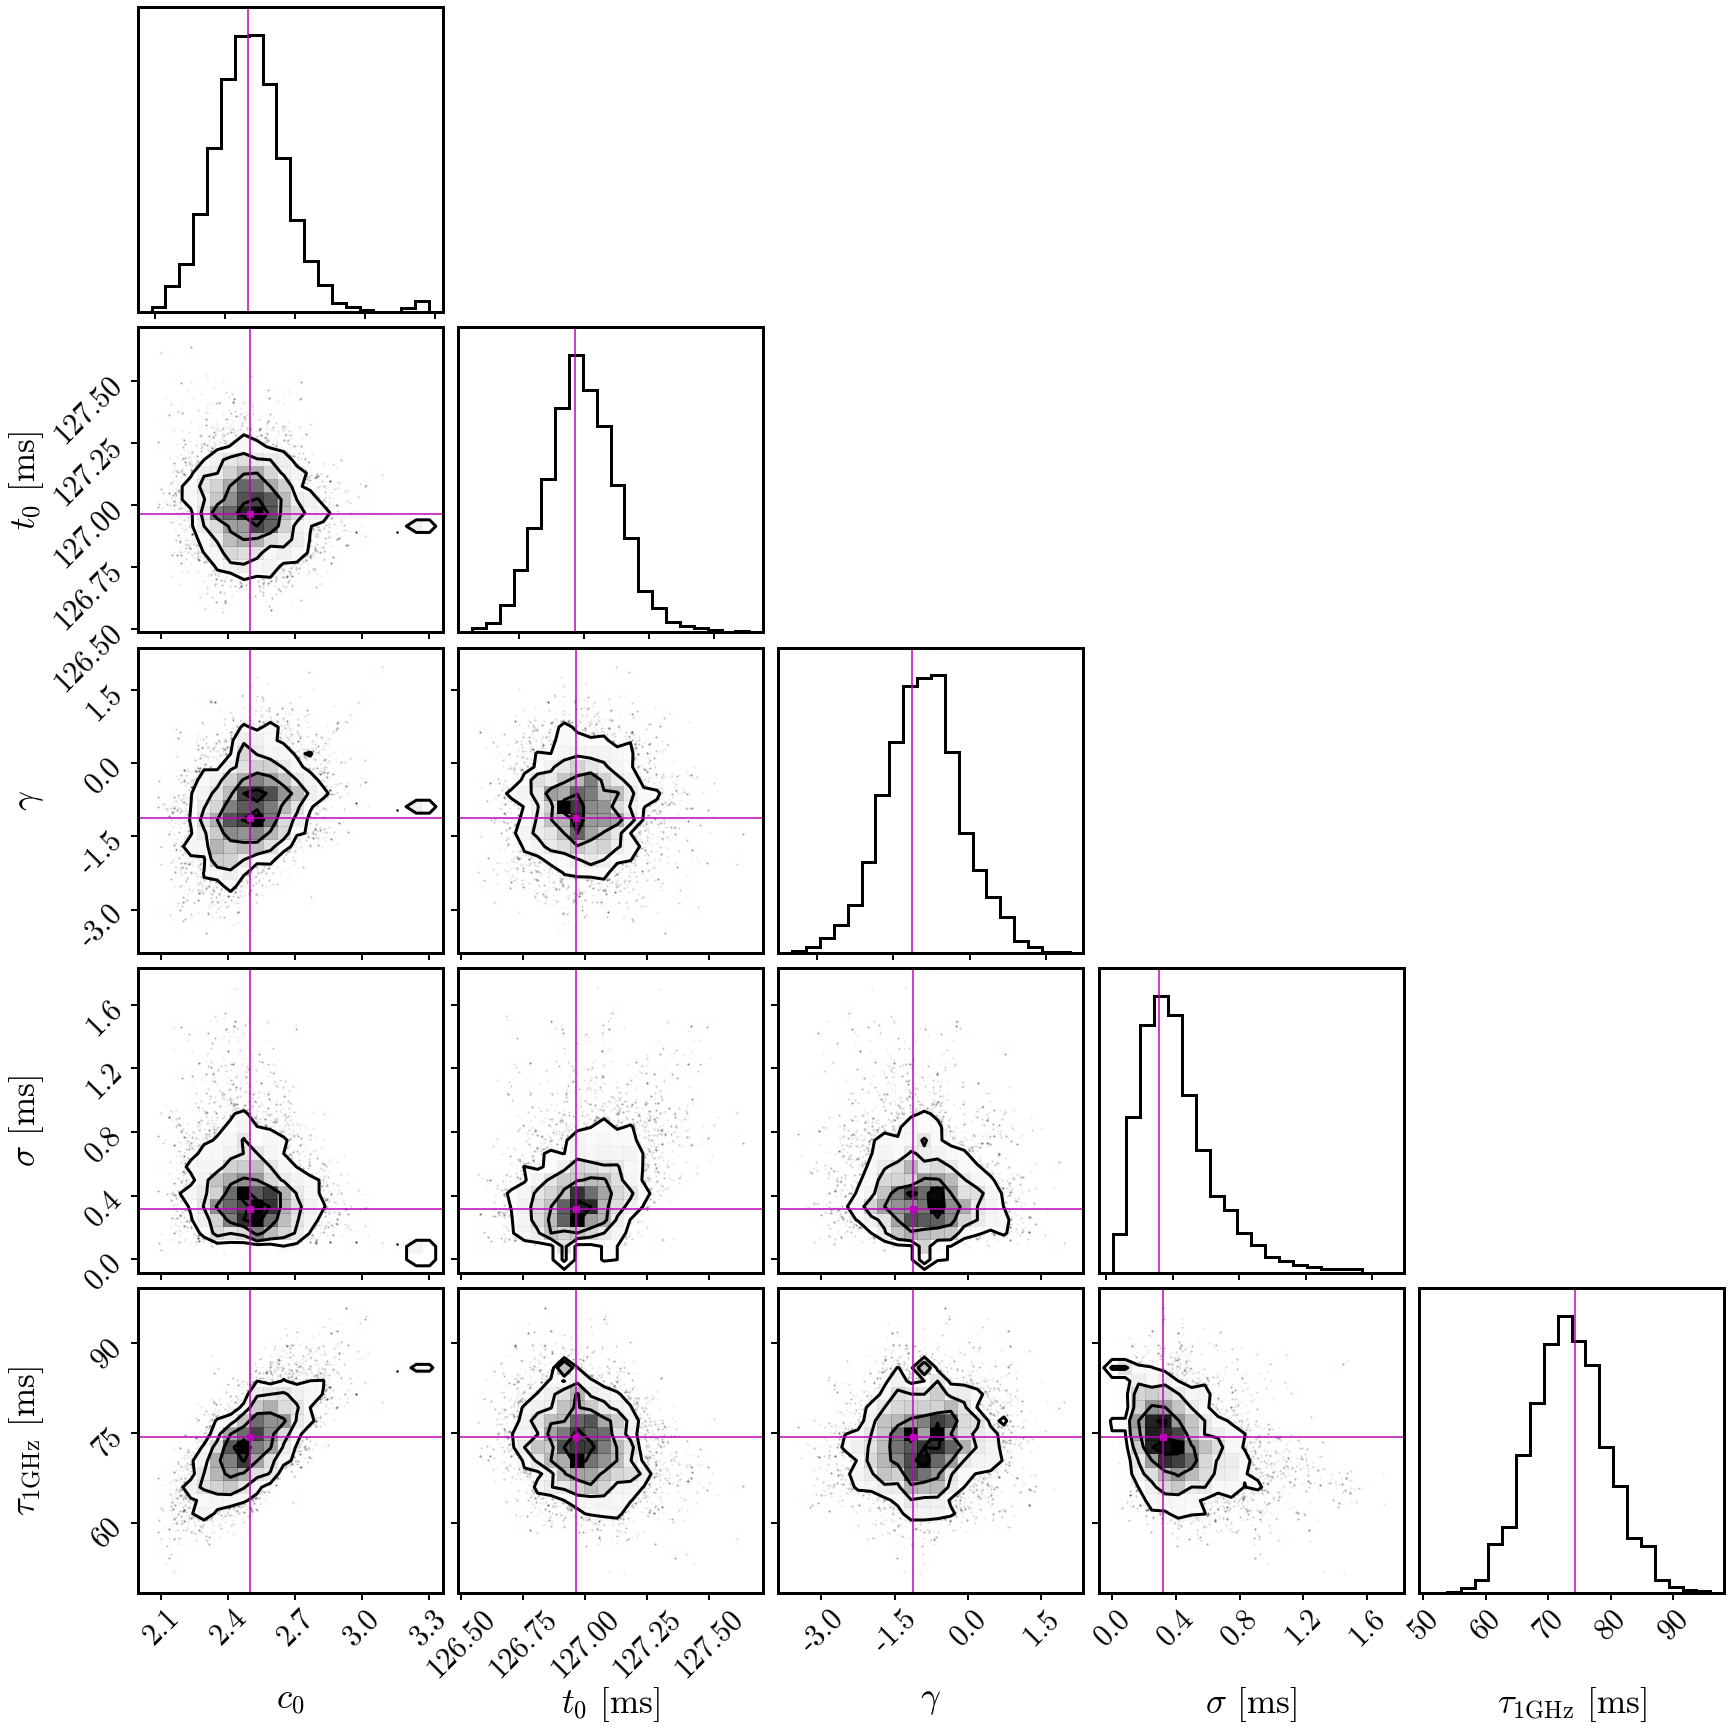

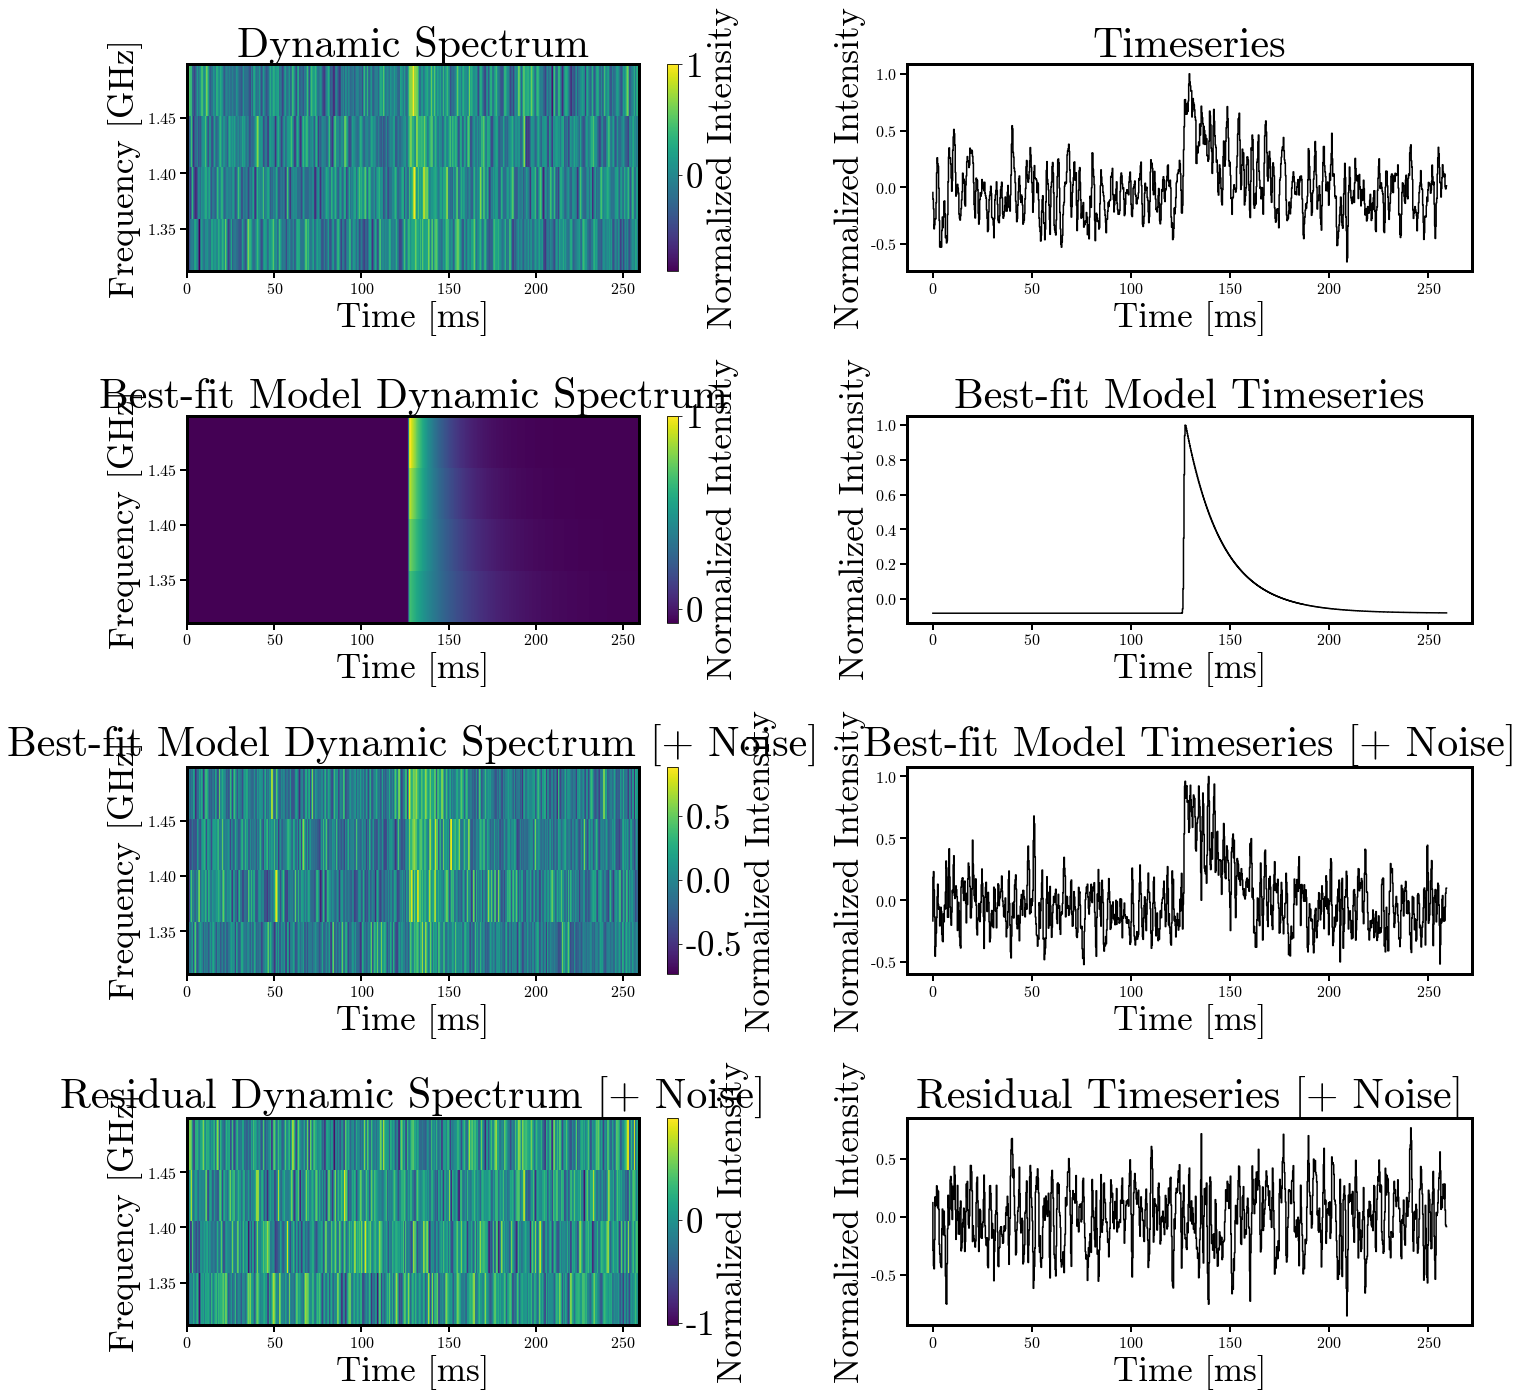

Mean acceptance fraction: 0.5018


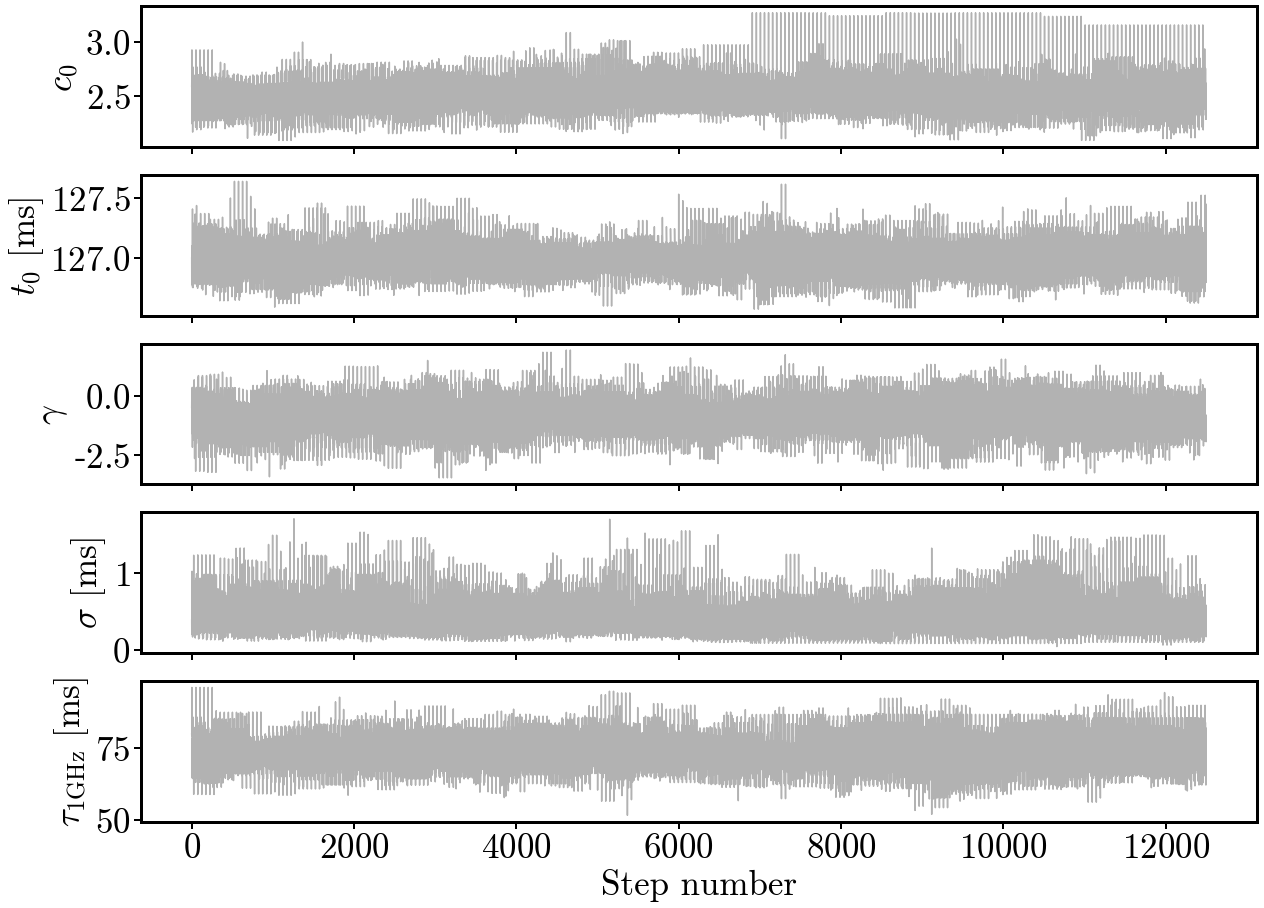

In [41]:
# Plot the data and the best-fit model
best_fit_index = np.argmax(best_sampler.get_log_prob(discard=burn_in, flat=True))
best_fit_index = np.argmax(log_prob)
best_fit_params = samples[best_fit_index]

print(f'Best Fit Params: {best_fit_params}')

rcParams['font.size'] = 35

# Plot the corner plot
# Define figure size before creating the corner plot
fig = plt.figure(figsize=(25, 25))  # Adjust width and height

labels = [r'$c_0$', r'$t_0$ [ms]', r'$\gamma$', r'$\sigma$ [ms]', r'$\tau_\mathrm{1GHz}$ [ms]']

fig = corner.corner(relevant_samples, labels=labels, truths=best_fit_params, fig=fig, truth_color='m', hist_kwargs={'linewidth': 3, 'histtype': 'step'}, contour_kwargs={'linewidths': 3})

for ax in fig.axes:
    # Spine widths
    ax.spines['top'].set_linewidth(3)
    ax.spines['bottom'].set_linewidth(3)
    ax.spines['left'].set_linewidth(3)
    ax.spines['right'].set_linewidth(3)

    # Tick parameters
    ax.tick_params(which='both', width=2)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=5)
    ax.tick_params(which='minor', axis='y', length=5)
    ax.tick_params(axis='both', labelsize=30)

fig.savefig(f'{name}_corner.pdf', bbox_inches = 'tight')
plt.show()

# Compute the model spectrum using the best-fit parameters
best_fit_model = model_instance.model(best_fit_params, model_type=best_model)

# Normalized data
norm_data = model_instance.data - np.mean(model_instance.data)
norm_data = norm_data / np.max(norm_data)

data_timeseries = np.sum(norm_data, axis=0)
norm_data_timeseries = data_timeseries - np.mean(data_timeseries)
norm_data_timeseries = norm_data_timeseries / np.max(norm_data_timeseries)

data_spectrum = np.sum(norm_data, axis=1)
norm_data_spectrum = data_spectrum - np.mean(data_spectrum)
norm_data_spectrum = norm_data_spectrum / np.max(norm_data_spectrum)

# Normalized model
norm_model = best_fit_model - np.mean(best_fit_model)
norm_model = norm_model / np.max(norm_model)

norm_model_timeseries = np.sum(norm_model, axis = 0)
norm_model_timeseries = norm_model_timeseries - np.mean(norm_model_timeseries)
norm_model_timeseries = norm_model_timeseries / np.max(norm_model_timeseries)

norm_model_spectrum = np.sum(norm_model, axis = 1)
norm_model_spectrum = norm_model_spectrum - np.mean(norm_model_spectrum)
norm_model_spectrum = norm_model_spectrum / np.max(norm_model_spectrum)

# Plot the data and the best-fit model separately for comparison
fig = plt.figure(figsize=(20, 20))

for i in range(1, 9):
    plt.subplot(4, 2, i)
    ax = plt.gca()
    
    # Spine widths
    ax.spines['top'].set_linewidth(3)
    ax.spines['bottom'].set_linewidth(3)
    ax.spines['left'].set_linewidth(3)
    ax.spines['right'].set_linewidth(3)

    # Tick parameters
    ax.tick_params(which='both', width=2)
    ax.tick_params(which='major', length=7)
    ax.tick_params(which='minor', length=5)
    ax.tick_params(which='minor', axis='y', length=5)
    ax.tick_params(axis='both', labelsize=16)

# Plot the data
plt.subplot(4, 2, 1)
extent = [time[0], time[-1], freq[0], freq[-1]]
plt.imshow(norm_data, extent=extent, aspect='auto', origin='upper', cmap='viridis', interpolation='nearest')
plt.colorbar(label='Normalized Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Dynamic Spectrum')

plt.subplot(4, 2, 2)
plt.step(time, norm_data_timeseries, c='k')
plt.xlabel('Time [ms]')
plt.ylabel('Normalized Intensity')
plt.title('Timeseries')

# Plot the best-fit model
plt.subplot(4, 2, 3)
plt.imshow(norm_model, extent=extent, aspect='auto', origin='upper', cmap='viridis', interpolation='nearest')
#plt.imshow(norm_noisy_model, extent=extent, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Normalized Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Best-fit Model Dynamic Spectrum')

plt.subplot(4, 2, 4)
plt.step(time, norm_model_timeseries, c='k')
#plt.plot(time, norm_noisy_timeseries)
plt.xlabel('Time [ms]')
plt.ylabel('Normalized Intensity')
plt.title('Best-fit Model Timeseries')

# Plot the best-fit model with added noise (based on the original data)
# Generate synthetic noise with the same shape as the model
#noise = np.random.normal(loc=0.0, scale=model_instance.noise_std[:, np.newaxis], size=best_fit_model.shape)
noise_sigma = model_instance.noise_std * 1.5
noise = np.random.lognormal(mean=0.0, sigma=noise_sigma[:, np.newaxis], size=best_fit_model.shape)

# Add the synthetic noise to the fitted model
noisy_model = best_fit_model + savgol_filter(noise, 7, 3)
norm_noisy_model = noisy_model - np.mean(noisy_model)
norm_noise_model = norm_noisy_model / np.max(norm_noisy_model)

# Integrate to get the noisy timeseries
noisy_timeseries = np.nansum(norm_noisy_model, axis = 0)
norm_noisy_timeseries = noisy_timeseries - np.mean(noisy_timeseries)
norm_noisy_timeseries = norm_noisy_timeseries / np.max(norm_noisy_timeseries)
noisy_spectrum = np.nansum(norm_noisy_model, axis = 1)
norm_noisy_spectrum = noisy_spectrum / np.max(noisy_spectrum)

plt.subplot(4, 2, 5)
#plt.imshow(norm_model, extent=extent, aspect='auto', origin='lower', cmap='viridis')
plt.imshow(norm_noisy_model, extent=extent, aspect='auto', origin='upper', cmap='viridis', interpolation='nearest')
plt.colorbar(label='Normalized Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Best-fit Model Dynamic Spectrum [+ Noise]')

plt.subplot(4, 2, 6)
#plt.plot(time, norm_model_timeseries)
plt.step(time, norm_noisy_timeseries, c='k')
plt.xlabel('Time [ms]')
plt.ylabel('Normalized Intensity')
plt.title('Best-fit Model Timeseries [+ Noise]')

# Plot the residuals
plt.subplot(4, 2, 7)
plt.imshow(norm_data - norm_noisy_model, extent=extent, aspect='auto', origin='upper', cmap='viridis', interpolation='nearest')
plt.colorbar(label='Normalized Intensity')
plt.xlabel('Time [ms]')
plt.ylabel('Frequency [GHz]')
plt.title('Residual Dynamic Spectrum [+ Noise]')

plt.subplot(4, 2, 8)
plt.step(time, norm_data_timeseries - norm_noisy_timeseries, c='k')
plt.xlabel('Time [ms]')
plt.ylabel('Normalized Intensity')
plt.title('Residual Timeseries [+ Noise]')

plt.tight_layout()

fig.savefig(f'{name}_finalmodel_eightpanel.pdf', bbox_inches = 'tight')

plt.show()

# Check the mean acceptance fraction
print("Mean acceptance fraction:", np.mean(best_sampler.acceptance_fraction))

# Trace plots to assess convergence
ndim = len(labels)
fig, axes = plt.subplots(ndim, figsize=(20, 15), sharex=True)
for i in range(ndim):
    axes[i].plot(samples[:, i], "k", alpha=0.3)
    axes[i].set_ylabel(labels[i])
    # Spine widths
    axes[i].spines['top'].set_linewidth(3)
    axes[i].spines['bottom'].set_linewidth(3)
    axes[i].spines['left'].set_linewidth(3)
    axes[i].spines['right'].set_linewidth(3)

    # Tick parameters
    axes[i].tick_params(which='both', width=2)
    axes[i].tick_params(which='major', length=7)
    axes[i].tick_params(which='minor', length=5)
    axes[i].tick_params(which='minor', axis='y', length=5)
axes[-1].set_xlabel("Step number")

fig.savefig(f'{name}_traces.pdf', bbox_inches = 'tight')

plt.show()


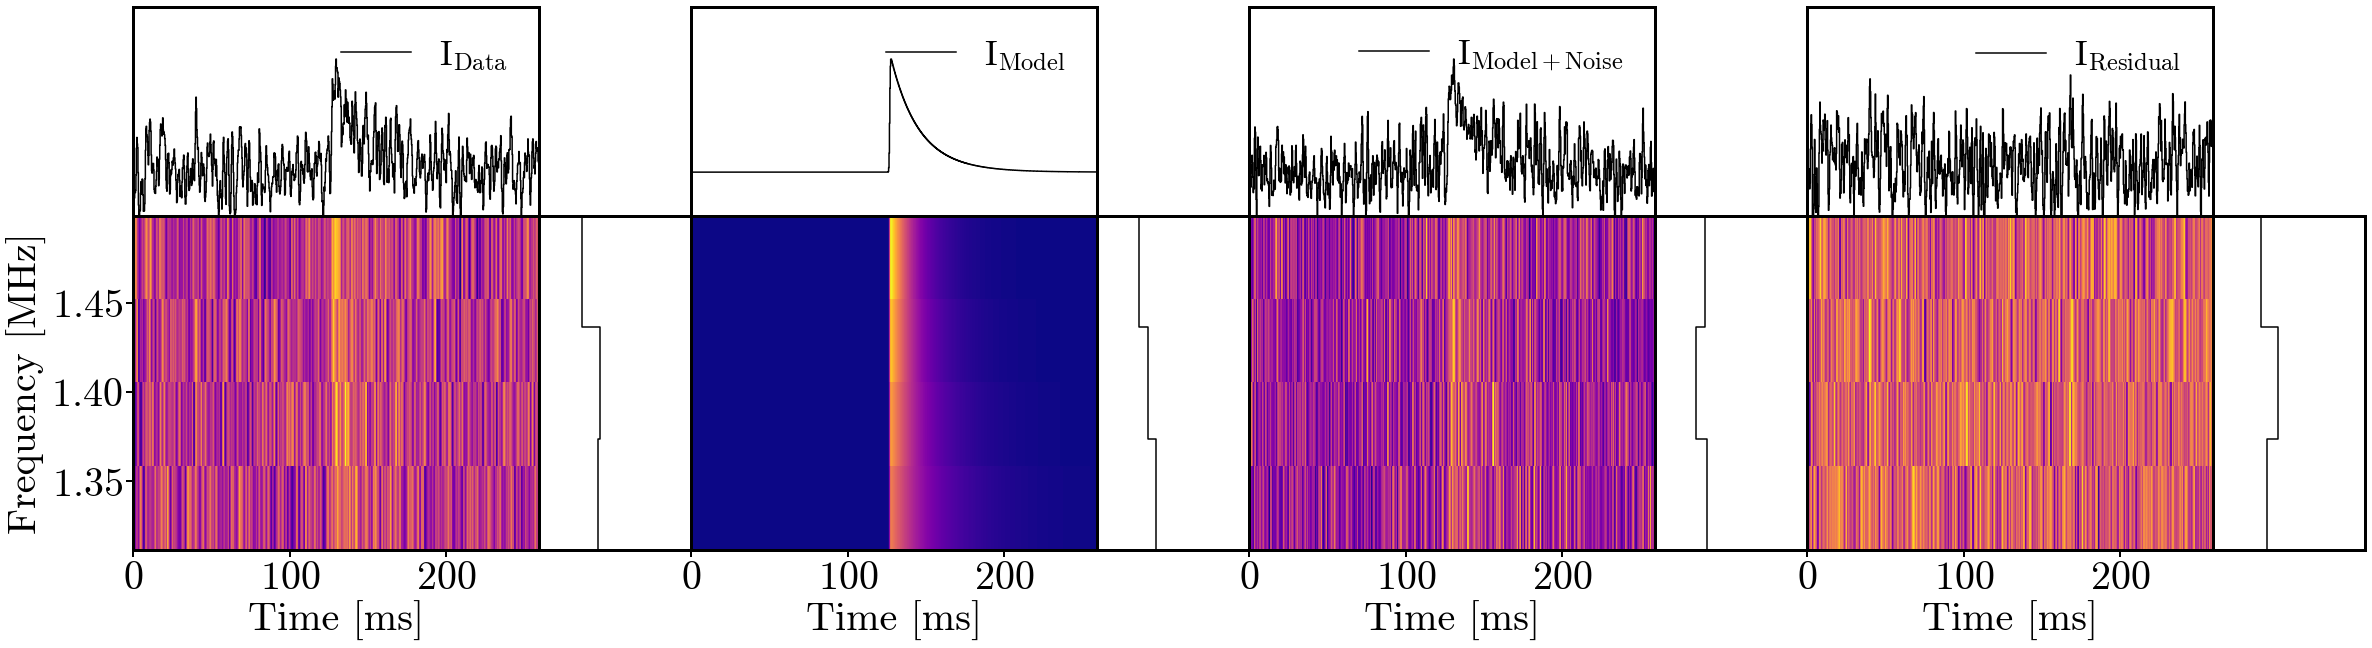

In [37]:
fig, axes = plt.subplots(
    nrows=2, ncols=8, sharex=False, sharey=False,
    gridspec_kw={'height_ratios': [1.25, 2],
                 'width_ratios': [2, 0.75, 2, 0.75, 2, 0.75, 2, 0.75]},
    figsize=(40, 10)
)

rcParams['font.size'] = 40

# Increase border thickness and set tick parameters for every axis
for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_linewidth(3)
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
        ax.tick_params(which='both', width=2)
        ax.tick_params(which='major', length=7)
        ax.tick_params(which='minor', length=5)
        ax.tick_params(which='minor', axis='y', length=5)


extent = [time[0], time[-1], freq[0], freq[-1]]

# ----- PANEL 1: Real Data -----
# Timeseries (top left of panel 1: column 0)
axes[0, 0].step(time, norm_data_timeseries, where='mid', c='k', alpha=1, label='I$_{\mathrm{Data}}$')
axes[0, 0].set_yticks([])
axes[0, 0].set_ylim(-0.5, 1.5)
axes[0, 0].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 0].set_xlim(sim_timesamples[0], sim_timesamples[-1])
axes[0, 0].legend(loc='upper right', fontsize=35, frameon=False)

# Waterfall (bottom left of panel 1: column 0)
axes[1, 0].imshow(norm_data, extent=extent, cmap='plasma', aspect='auto', interpolation='nearest')
axes[1, 0].set_ylabel('Frequency [MHz]')
axes[1, 0].set_xlabel('Time [ms]')

# Spectrum (bottom right of panel 1: column 1)
axes[1, 1].step(np.flip(norm_data_spectrum), freq, where='mid', c='k', alpha=1)
#axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_xticks([])
axes[1, 1].set_xlim(-2, 4)
axes[1, 1].set_ylim(freq[0], freq[-1])
axes[1, 1].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 1)
axes[0, 1].axis('off')
axes[0, 1].set_visible(False)

# ----- PANEL 2: Simulated Data (Model) -----
# Timeseries (top left of panel 1: column 0)
axes[0, 2].step(time, norm_model_timeseries, where='mid', c='k', alpha=1, label='I$_{\mathrm{Model}}$')
axes[0, 2].set_yticks([])
axes[0, 2].set_ylim(-0.5, 1.5)
axes[0, 2].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 2].set_xlim(time[0], time[-1])
axes[0, 2].legend(loc='upper right', fontsize=35, frameon=False)

# Waterfall (bottom left of panel 1: column 0)
axes[1, 2].imshow(norm_model, extent=extent, cmap='plasma', aspect='auto', interpolation='nearest')
axes[1, 2].set_xlabel('Time [ms]')
axes[1, 2].set_yticks([])

# Spectrum (bottom right of panel 1: column 1)
axes[1, 3].step(np.flip(norm_model_spectrum), freq, where='mid', c='k', alpha=1)
#axes[1, 1].set_xlabel('Intensity')
axes[1, 3].set_xticks([])
axes[1, 3].set_xlim(-4, 8)
axes[1, 3].set_ylim(freq[0], freq[-1])
axes[1, 3].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 1)
axes[0, 3].axis('off')
axes[0, 3].set_visible(False)

# ----- PANEL 3: Simulated Data + Noise -----
# Timeseries (top left of panel 2: column 2)
axes[0, 4].step(time, norm_noisy_timeseries, where='mid', c='k', alpha=1, label='I$_{\mathrm{Model+Noise}}$')
axes[0, 4].set_yticks([])
axes[0, 4].set_ylim(-0.5, 1.5)
axes[0, 4].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 4].set_xlim(time[0], time[-1])
axes[0, 4].legend(loc='upper right', fontsize=35, frameon=False)

# Waterfall (bottom left of panel 2: column 2)
axes[1, 4].imshow(norm_noisy_model, extent=extent, cmap='plasma', aspect='auto', interpolation='nearest')
#axes[1, 2].set_ylabel('Frequency [MHz]')
axes[1, 4].set_yticks([])
axes[1, 4].set_xlabel('Time [ms]')

# Spectrum (bottom right of panel 2: column 3)
axes[1, 5].step(np.flip(norm_noisy_spectrum), freq, where='mid', c='k', alpha=1)
#axes[1, 3].set_xlabel('Intensity')
axes[1, 5].set_xticks([])
axes[1, 5].set_xlim(-4, 8)
axes[1, 5].set_ylim(freq[0], freq[-1])
axes[1, 5].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 3)
axes[0, 5].axis('off')
axes[0, 5].set_visible(False)

# ----- PANEL 4: Residuals -----
# Timeseries residual (top left of panel 3: column 4)
axes[0, 6].step(time, norm_data_timeseries - norm_noisy_timeseries, where='mid', c='k', alpha=1, label='I$_{\mathrm{Residual}}$')
axes[0, 6].set_yticks([])
axes[0, 6].set_ylim(-0.5, 1.5)
axes[0, 6].tick_params(axis='x', bottom=False, top=False, labelbottom=False)
axes[0, 6].set_xlim(time[0], time[-1])
axes[0, 6].legend(loc='upper right', fontsize=35, frameon=False)

# Waterfall residual (bottom left of panel 3: column 4)
axes[1, 6].imshow(norm_data - norm_noisy_model, extent=extent, cmap='plasma', aspect='auto', interpolation='nearest')
#axes[1, 4].set_ylabel('Frequency [MHz]')
axes[1, 6].set_yticks([])
axes[1, 6].set_xlabel('Time [ms]')

# Spectrum for residuals (bottom right of panel 3: column 5)
axes[1, 7].step(np.flip(norm_data_spectrum - norm_noisy_spectrum), freq, where='mid', c='k', alpha=1, label='I$_{\mathrm{norm}}$')
#axes[1, 5].set_xlabel('Intensity')
axes[1, 7].set_xticks([])
axes[1, 7].set_xlim(-4, 8)
axes[1, 7].set_ylim(freq[0], freq[-1])
axes[1, 7].tick_params(axis='y', left=False, right=False, labelleft=False)

# Hide the unused top axis for spectrum (column 5)
axes[0, 7].axis('off')
axes[0, 7].set_visible(False)
plt.subplots_adjust(hspace=0, wspace=0)

fig.savefig(f'{name}_finalmodel_fourpanel.pdf', bbox_inches = 'tight')

plt.show()


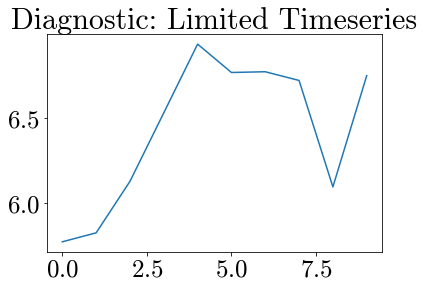

100%|██████████| 1536/1536 [00:00<00:00, 15219.55it/s]


[[Model]]
    Model(lorentz)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 672
    # data points      = 32
    # variables        = 3
    chi-square         = 750.237737
    reduced chi-square = 25.8702668
    Akaike info crit   = 106.948936
    Bayesian info crit = 111.346143
    R-squared          = 0.10969752
[[Variables]]
    gamma1:  0.58127960 +/- 6277.50303 (1079945.53%) (init = 1)
    m1:      275.830232 +/- 2948707.74 (1069029.93%) (init = 1)
    c:      -3.62949498 +/- 1.29813697 (35.77%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(gamma1, m1) = -1.0000
    C(gamma1, c)  = -0.5912
    C(m1, c)      = +0.5912


FileNotFoundError: [Errno 2] No such file or directory: '/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/nihari/nihari_221219aabz_acf_fit.pdf'

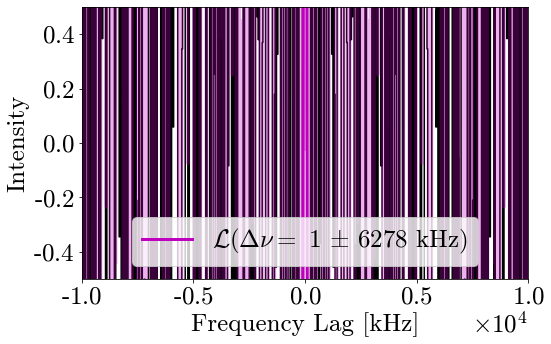

In [325]:
for i in np.arange(0, 3):
    #spec_norm = spectrum / np.max(spectrum)
    intensity_tshape = intensity.shape[1]
    intensity_off = intensity[i:i+1536, 0:150]
    offspec_mean = np.nanmean(intensity_off)
    outer_bound = 5
    spectrum_lim = np.nansum(intensity[i:i+1536, intensity_tshape//2 - outer_bound:intensity_tshape//2 + outer_bound], axis=1)

    fig = plt.figure()
    plt.plot(np.nansum(intensity[i:i+1536, intensity_tshape//2 - outer_bound:intensity_tshape//2 + outer_bound], axis=0))
    plt.title('Diagnostic: Limited Timeseries')
    plt.show()

    spec_norm = spectrum_lim #/ np.max(spectrum_lim)
    acf=sct.autocorr(spec_norm, offspec_mean = offspec_mean)
    lags=np.arange(len(acf))+1
    acf=acf[1:]
    lags=lags[1:]
    acf=np.concatenate((acf[::-1],acf))
    lags=np.concatenate((-1*lags[::-1],lags))*fres_kHz

    lag_range_for_fit=500 #somewhat arbitrary, 2000 works well to successfully fit the central peak

    gmodel = Model(sct.lorentz)
    acf_for_fit = acf[int(len(acf)/2.)-int(lag_range_for_fit/fres_kHz):int(len(acf)/2.)+int(lag_range_for_fit/fres_kHz)]
    lags_for_fit = lags[int(len(acf)/2.)-int(lag_range_for_fit/fres_kHz):int(len(acf)/2.)+int(lag_range_for_fit/fres_kHz)]
    #result = gmodel.fit(acf_for_fit, x=lags_for_fit, gamma1=10, m1=1,gamma2=100,m2=1, c=0)
    result = gmodel.fit(acf_for_fit, x=lags_for_fit, gamma1=1, m1=1,c=0)
    print(result.fit_report())

    fig = plt.figure(figsize = (8, 5))

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.xaxis.get_major_formatter().set_scientific(True)
    ax.xaxis.get_major_formatter().set_powerlimits((-4, 4))

    label_str = r'$\mathcal{L}(\Delta \nu =$ ' + str(round(result.params['gamma1'].value)) + r' $\pm$ ' + str(round(result.params['gamma1'].stderr)) + ' kHz)'


    plt.step(lags, acf, c = 'k')
    plt.plot(lags, sct.lorentz(lags, result.params['gamma1'], result.params['m1'], result.params['c']), c = 'm', lw = 3, label = label_str)
    plt.plot(lags, acf - sct.lorentz(lags, result.params['gamma1'], result.params['m1'], result.params['c']) - 0.1, c = 'm', alpha = 0.3, lw = 3)

    plt.xlim(-10e3, 10e3)
    plt.ylim(-0.5, .5)
    plt.xlabel('Frequency Lag [kHz]')
    plt.ylabel('Intensity')
    plt.legend()
    fig.savefig(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/figures/{name.split("_")[0]}/{name}_acf_fit.pdf', bbox_inches = 'tight')
    plt.show()

$L_x L_g \lesssim \frac{D_s^2}{2 \pi \nu^2(1+z)} \frac{\nu_{\mathrm{DC}}}{t_{\text {scatt }}}$.

In [18]:
def Lx(nu, dso, z, sbw, tau, Lg):
    lx = (dso**2 * sbw) / (Lg * (2 * np.pi * nu**2) * (1+z) * tau)
    return lx

with open(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/localizations/dsa_localizations.json', 'r') as file:
    loc_data = json.load(file)

#localization = ['20h50m28.59s', '+73d54m00.0s']
#z_source = 0.0740
localization = [loc_data[f'{name.split("_")[0]}']["localization"]["ra"], loc_data[f'{name.split("_")[0]}']["localization"]["dec"]]
#z_source = loc_data[f'{name.split("_")[0]}']["z_source"]
z_source = 0.239 # corresponds to a comoving distance of 1 Gpc
print('localization:', localization)
print('z_source:', z_source)

gal_dist = 30 #kpc
coord_icrs = SkyCoord(localization[0], localization[1], frame = 'icrs')
coord_galactic = coord_icrs.galactic
ra_gal_deg = coord_galactic.l.deg
dec_gal_deg = coord_galactic.b.deg
output = get_dm_full(ra_gal_deg, dec_gal_deg, gal_dist)

print('NE2001 Sightline Estimates:')
print('________________________________')
ne2001_sbw_1p4GHz = output["SBW"]*(1.4)**best_fit_params_dict["alpha"][0]
print(f'SBW (1.4 GHz): {1e3*ne2001_sbw_1p4GHz} kHz')
ne2001_tau_1p4GHz = output["TAU"]*(1.4)**(-1 * best_fit_params_dict["alpha"][0])
print(f'Tau (1.4 GHz): {ne2001_tau_1p4GHz} ms')
print('\n')

# Perform two-screen calculation
print('Two Screen Analysis:')
print('________________________________')
# Define a cosmology, e.g., H0 = 70 km/s/Mpc and Omega_m = 0.3
H0 = 70
Om0 = 0.3
cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
#dso = cosmo.comoving_distance(z_source).to(u.kpc) # comoving distance
dso = 1*u.Gpc
print(f'Comoving Distance to Source: {dso}')
sbw_1p4GHz = result.params['gamma1'].value * u.kHz
print(f'Measured SBW (1.4 GHz): {sbw_1p4GHz}')
nu = (1.4 * u.GHz).to(u.kHz)
print(f'Observing Frequency: {nu}')
tau_1p4GHz = best_fit_params_dict['tau_1GHz'][0] * 1.4**(-1*best_fit_params_dict['alpha'][0]) * u.ms
print(f'Measured Tau (1.4 GHz): {tau_1p4GHz}')
lg = 1 * u.kpc
print(f'L_g (MW Thick Disk): {lg}')
lx = Lx(nu, dso, z_source, sbw_1p4GHz, tau_1p4GHz, lg)
lx_kpc = lx.to(u.kpc)
print(f'Upper Limit on Source-to-Screen Distance: {lx_kpc}')



localization: ['05h52m45.12s', '+74d12m01.7s']
z_source: 0.239
NE2001 Sightline Estimates:
________________________________
SBW (1.4 GHz): 1260.8131200000971 kHz
Tau (1.4 GHz): 0.00014642336526446184 ms


Two Screen Analysis:
________________________________
Comoving Distance to Source: 1.0 Gpc
Measured SBW (1.4 GHz): 33.896493169002476 kHz
Observing Frequency: 1400000.0 kHz
Measured Tau (1.4 GHz): 0.05245390441138955 ms
L_g (MW Thick Disk): 1.0 kpc
Upper Limit on Source-to-Screen Distance: 42.35158839068933 kpc


In [24]:
two_screen_dict = {}
two_screen_dict["localization"] = localization
two_screen_dict["z_source"] = z_source
two_screen_dict["cosmology"] = [H0, Om0]
two_screen_dict["comoving_distance"] = dso.value
two_screen_dict["ra_gal"] = ra_gal_deg
two_screen_dict["dec_gal"] = dec_gal_deg
two_screen_dict["ne2001_fulldict"] = output
two_screen_dict["ne2001_sbw_1.4GHz"] = ne2001_sbw_1p4GHz
two_screen_dict["ne2001_tau_1.4GHz"] = ne2001_tau_1p4GHz
two_screen_dict["sbw_1.4GHz"] = sbw_1p4GHz.value
two_screen_dict["tau_1.4GHz"] = tau_1p4GHz.value
two_screen_dict["L_G"] = lg.value
two_screen_dict["L_X"] = lx_kpc.value

best_fit_params_dict["two_screen"] = two_screen_dict


In [25]:
with open(f'/media/ubuntu/ssd/jfaber/dsa110-scat/codetections/params/{name.split("_")[0]}_best_fit_params.json', 'w') as f:
    json.dump(best_fit_params_dict, f)